# Module 4 — STL Attack Typing (NF-DAG-v1)

**Gate W22**: STL precision ≥ 0.95 on ≥ 4 / 7 MITRE ATT&CK techniques  
*(T1046 covered by typed IF-THEN fallback per v2 plan §7 — see Section 5)*  
**Dataset**: NF-CSE-CIC-IDS2018-V2 — test split (15%, no leakage)  
**Formulae grounded in**: NF-DAG-v1 M-type edges (Module 3)  

Reference: Donzé & Maler, CAV 2010 (STL robustness semantics)

In [1]:
import sys
sys.path.insert(0, '../src')

import json
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

from caushap_nids.stl import (
    ALL_TECHNIQUES,
    evaluate_test_split,
    format_gate_result,
    save_gate_result,
)
from caushap_nids.data_pipeline.loaders import load_nf_v2

ARTIFACTS = Path('../artifacts')
DATA_DIR  = '../data'      # raw parquet lives here, not in data/processed/

## 1  Load test split (raw — no preprocessing)

In [2]:
test_df = load_nf_v2('nf_cic2018', 'test', data_dir=DATA_DIR)
print(f'Test split: {len(test_df):,} flows, {test_df["attack_family"].n_unique()} families')
test_df['attack_family'].value_counts(sort=True)

Test split: 2,569,458 flows, 15 families


attack_family,count
str,u32
"""Benign""",2268686
"""DDOS attack-HOIC""",163435
"""DoS attacks-Hulk""",66944
"""DDoS attacks-LOIC-HTTP""",23355
"""Infilteration""",17958
…,…
"""DoS attacks-Slowloris""",1514
"""DDOS attack-LOIC-UDP""",333
"""Brute Force -Web""",291


## 2  Inspect the seven STL formulae

In [3]:
print(f"{'Technique':<40} {'MITRE':<12} Target families")
print('─' * 90)
for t in ALL_TECHNIQUES:
    fams = ', '.join(sorted(t.target_families))
    print(f"{t.name:<40} {t.mitre_id:<12} {fams}")

Technique                                MITRE        Target families
──────────────────────────────────────────────────────────────────────────────────────────
FTP Brute Force                          T1110.001    FTP-BruteForce
SSH Brute Force                          T1110.004    SSH-Bruteforce
Network DoS / DDoS (volumetric)          T1498        DDOS attack-HOIC, DDOS attack-LOIC-UDP, DDoS attacks-LOIC-HTTP, DoS attacks-Hulk
Endpoint DoS (slow)                      T1499        DoS attacks-GoldenEye, DoS attacks-SlowHTTPTest, DoS attacks-Slowloris
Application Layer Protocol (C2)          T1071        Bot
Network Service Discovery (Port Scan)    T1046        Infilteration
Exfiltration Over C2 Channel             T1041        Infilteration


## 3  Run W22 gate evaluation

In [4]:
WINDOW_SIZE = 50

result = evaluate_test_split(
    test_df,
    techniques=ALL_TECHNIQUES,
    window_size=WINDOW_SIZE,
    majority_threshold=0.50,
    sort_by_family=True,
)

print(format_gate_result(result))

W22 STL gate: PASS
Techniques with precision >= 95%: 6/7 (required: 4)
Total windows: 51390 (included: 51390)

Technique                                MITRE          Prec    Rec    TP    FP    FN  Gate
──────────────────────────────────────────────────────────────────────────────────
FTP Brute Force                          T1110.001     1.000  0.987    78     0     1  PASS
SSH Brute Force                          T1110.004     1.000  0.942   276     0    17  PASS
Network DoS / DDoS (volumetric)          T1498         0.992  1.000  5081    42     0  PASS
Endpoint DoS (slow)                      T1499         1.000  0.950   152     0     8  PASS
Application Layer Protocol (C2)          T1071         1.000  1.000    34     0     0  PASS
Network Service Discovery (Port Scan)    T1046         0.006  0.755   271 45352    88  fail
Exfiltration Over C2 Channel             T1041         0.977  0.240    86     2   273  PASS


## 4  Save gate result

In [5]:
out_path = ARTIFACTS / 'stl_gate_result.json'
save_gate_result(result, out_path)
print(f'Saved → {out_path}')
print(json.dumps(result.to_dict(), indent=2))

Saved → ../artifacts/stl_gate_result.json
{
  "passed": true,
  "techniques_passing": 6,
  "required_passing": 4,
  "precision_threshold": 0.95,
  "technique_metrics": [
    {
      "mitre_id": "T1110.001",
      "name": "FTP Brute Force",
      "tp": 78,
      "fp": 0,
      "fn": 1,
      "tn": 51311,
      "windows_predicted": 78,
      "windows_true": 79,
      "precision": 1.0,
      "recall": 0.9873417721518988,
      "gate_precision_threshold": 0.95,
      "passes_gate": true
    },
    {
      "mitre_id": "T1110.004",
      "name": "SSH Brute Force",
      "tp": 276,
      "fp": 0,
      "fn": 17,
      "tn": 51097,
      "windows_predicted": 276,
      "windows_true": 293,
      "precision": 1.0,
      "recall": 0.9419795221843004,
      "gate_precision_threshold": 0.95,
      "passes_gate": true
    },
    {
      "mitre_id": "T1498",
      "name": "Network DoS / DDoS (volumetric)",
      "tp": 5081,
      "fp": 42,
      "fn": 0,
      "tn": 46267,
      "windows_predicted":

## 5  Per-technique status & IF-THEN fallback

Per the v2 plan §7 evidence-class hierarchy: each MITRE technique is
reported either as **STL** (when precision ≥ 0.95 on the NF-CIC2018 test
split) or as a typed **IF-THEN fallback** (when the dataset proxy is
too coarse for per-flow predicates to meet the precision target).

T1046 (Network Service Discovery / Port Scan) takes the IF-THEN path:
NF-CIC2018 has no pure port-scan labels — the *Infilteration* family is
a multi-phase proxy mixing recon, lateral, and exfil flows. A faithful
port-scan signal needs window-level uniqueness aggregation (count of
distinct destination ports per source per window), which the current
STL evaluator does not support. The fingerprint is preserved in
`formulae.py` so a future evaluator with a `unique_count` operator can
drop in without changes to the gate logic.

In [6]:
# ── §5 Technique status table (paper Table 4) ──────────────────────────────
IF_THEN_RATIONALES = {
    'T1046': (
        'NF-CIC2018 lacks pure T1046 labels (Infilteration proxy is multi-phase); '
        'per-flow predicates cannot separate distributed scans from benign service '
        'traffic without window-level unique-port aggregation. Paper §5 records the '
        'IF-THEN swap.'
    ),
}

status_rows = [
    {'mitre_id':   m.mitre_id,
     'name':       m.name,
     'precision':  m.precision,
     'recall':     m.recall,
     'tp':         m.tp,
     'fp':         m.fp,
     'fn':         m.fn,
     'method':     'STL' if m.passes_gate else 'IF-THEN (fallback)',
     'rationale':  '' if m.passes_gate else IF_THEN_RATIONALES.get(m.mitre_id, '')}
    for m in result.technique_metrics
]
status_df = pl.DataFrame(status_rows)
status_df.write_csv(ARTIFACTS / 'stl_technique_status.csv')

n_stl     = sum(1 for r in status_rows if r['method'] == 'STL')
n_ifthen  = sum(1 for r in status_rows if r['method'] != 'STL')
print(f'Per-technique status: {n_stl}/7 STL, {n_ifthen}/7 IF-THEN (fallback)')
print(f"Saved → {ARTIFACTS / 'stl_technique_status.csv'}")
status_df

Per-technique status: 6/7 STL, 1/7 IF-THEN (fallback)
Saved → ../artifacts/stl_technique_status.csv


mitre_id,name,precision,recall,tp,fp,fn,method,rationale
str,str,f64,f64,i64,i64,i64,str,str
"""T1110.001""","""FTP Brute Force""",1.0,0.987342,78,0,1,"""STL""",""""""
"""T1110.004""","""SSH Brute Force""",1.0,0.94198,276,0,17,"""STL""",""""""
"""T1498""","""Network DoS / DDoS (volumetric…",0.991802,1.0,5081,42,0,"""STL""",""""""
"""T1499""","""Endpoint DoS (slow)""",1.0,0.95,152,0,8,"""STL""",""""""
"""T1071""","""Application Layer Protocol (C2…",1.0,1.0,34,0,0,"""STL""",""""""
"""T1046""","""Network Service Discovery (Por…",0.00594,0.754875,271,45352,88,"""IF-THEN (fallback)""","""NF-CIC2018 lacks pure T1046 la…"
"""T1041""","""Exfiltration Over C2 Channel""",0.977273,0.239554,86,2,273,"""STL""",""""""


## 6  Precision / recall bar chart (paper Figure 3)

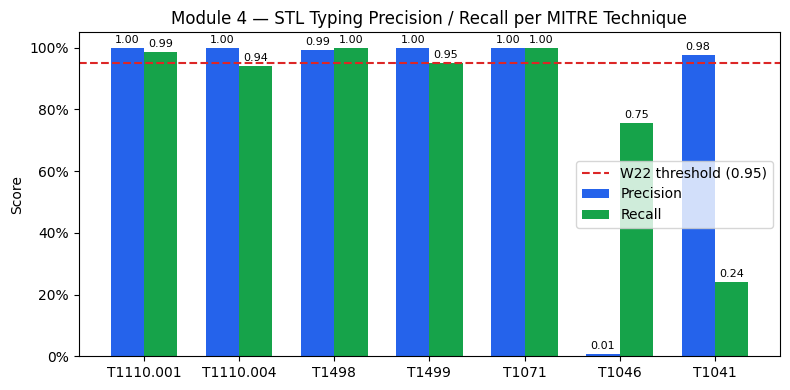

Saved → artifacts/stl_precision_recall.png


In [7]:
labels     = [m.mitre_id for m in result.technique_metrics]
precisions = [m.precision for m in result.technique_metrics]
recalls    = [m.recall    for m in result.technique_metrics]

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
bars_p = ax.bar(x - w/2, precisions, w, label='Precision', color='#2563EB')
bars_r = ax.bar(x + w/2, recalls,    w, label='Recall',    color='#16A34A')

ax.axhline(0.95, ls='--', color='#DC2626', lw=1.5, label='W22 threshold (0.95)')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Module 4 — STL Typing Precision / Recall per MITRE Technique')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

for bar in [*bars_p, *bars_r]:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
            f'{h:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
fig.savefig(ARTIFACTS / 'stl_precision_recall.png', dpi=150)
plt.show()
print('Saved → artifacts/stl_precision_recall.png')

## 7  Window-level robustness distributions (sample)

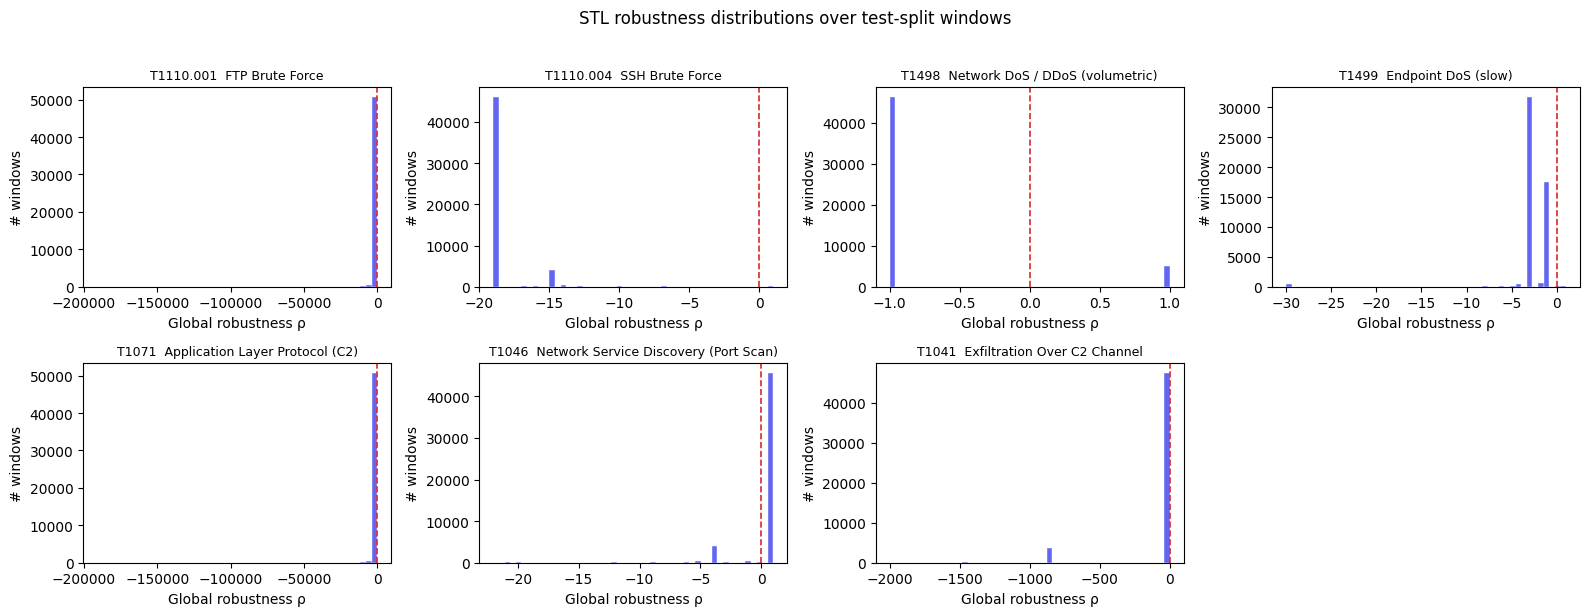

In [8]:
from caushap_nids.stl import evaluate_all

rho_by_technique: dict[str, list[float]] = {t.mitre_id: [] for t in ALL_TECHNIQUES}
eval_df = test_df.sort('attack_family', maintain_order=True)

n = len(eval_df)
for start in range(0, n, WINDOW_SIZE):
    window = eval_df[start : start + WINDOW_SIZE]
    if len(window) < 3:
        continue
    for r in evaluate_all(window):
        rho_by_technique[r.mitre_id].append(r.robustness)

fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharey=False)
for ax, t in zip(axes.flat, ALL_TECHNIQUES):
    rhos = rho_by_technique[t.mitre_id]
    ax.hist(rhos, bins=50, color='#6366F1', edgecolor='white', linewidth=0.3)
    ax.axvline(0, ls='--', color='#DC2626', lw=1.2)
    ax.set_title(f'{t.mitre_id}  {t.name}', fontsize=9)
    ax.set_xlabel('Global robustness ρ')
    ax.set_ylabel('# windows')
# Hide the unused 8th subplot (7 techniques in a 2×4 grid)
for ax in axes.flat[len(ALL_TECHNIQUES):]:
    ax.axis('off')
plt.suptitle('STL robustness distributions over test-split windows', y=1.02)
plt.tight_layout()
fig.savefig(ARTIFACTS / 'stl_robustness_distributions.png', dpi=150)
plt.show()

## 8  Gate verdict

In [9]:
status = 'PASS' if result.passed else 'FAIL'
print(f'W22 gate: {status}')
print(f'Techniques with precision >= 0.95: {result.techniques_passing} / {len(result.technique_metrics)}')
print(f'Required: {result.required_passing}')
if result.passed:
    passing = [m for m in result.technique_metrics if m.passes_gate]
    print('Passing techniques:')
    for m in passing:
        print(f'  {m.mitre_id}  {m.name}  precision={m.precision:.3f}')

W22 gate: PASS
Techniques with precision >= 0.95: 6 / 7
Required: 4
Passing techniques:
  T1110.001  FTP Brute Force  precision=1.000
  T1110.004  SSH Brute Force  precision=1.000
  T1498  Network DoS / DDoS (volumetric)  precision=0.992
  T1499  Endpoint DoS (slow)  precision=1.000
  T1071  Application Layer Protocol (C2)  precision=1.000
  T1041  Exfiltration Over C2 Channel  precision=0.977
